# Binning(Discretization)

In [ ]:
# Numerical data to Categoricaldata

In [3]:
#Discretization(bining): unsupervised ,supervised, custom binning
#binarization :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

# binning
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
# load the data 
df = pd.read_csv("DATASET/titanic.csv",usecols=['Age','Fare','Survived'])
df


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [3]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [4]:
df.shape

(891, 3)

In [5]:
df.dropna(inplace=True)

In [6]:
df.shape

(714, 3)

In [7]:
df.head(2)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833


In [8]:
X =df.iloc[:,1:]
y =df.iloc[:,0]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
# train your model
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

score = accuracy_score(y_test,y_pred)
print("accuracy_scor :",score)

cross =np.mean(cross_val_score(model,X_train,y_train,cv =10,scoring='accuracy'))
print('cross_val_score :',cross)

accuracy_scor : 0.6201117318435754
cross_val_score : 0.6542278127183788


In [11]:
# apply binning to training data
bin_age = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')
bin_fare =KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')

In [12]:
transform_ = ColumnTransformer([
    ('first',bin_age,[0]),
    ('second',bin_fare,[1])
],remainder='passthrough')

In [13]:
X_train_t =transform_.fit_transform(X_train)
X_test_t = transform_.transform(X_test)

In [14]:
print(transform_.named_transformers_['first'].n_bins_)
print(transform_.named_transformers_['second'].n_bins_)

[5]
[5]


In [15]:
print(transform_.named_transformers_['first'].bin_edges_)
print(transform_.named_transformers_['second'].bin_edges_)

[array([ 0.42      , 12.69444112, 27.07267822, 39.41919243, 54.3149696 ,
        80.        ])                                                   ]
[array([  0.        ,  42.21342362, 100.34239474, 186.45254786,
        376.60581786, 512.3292    ])                           ]


In [16]:
output =pd.DataFrame({
    'age':X_train['Age'],
    'age_transform':X_train_t[:,0],
    'Fare':X_train['Fare'],
    'fare_transform':X_train_t[:,1]
})

In [17]:
output['age_label'] = pd.cut(x =X_train['Age'],
                            bins=transform_.named_transformers_['first'].
                            bin_edges_[0].tolist())

In [18]:
output['fare_label'] = pd.cut(x =X_train['Fare'],
                            bins=transform_.named_transformers_['second'].
                            bin_edges_[0].tolist())

In [19]:
output.sample(5)

,age,age_transform,Fare,fare_transform,age_label,fare_label
446,13.00,1.0,19.5000,0.0,"(12.694, 27.073]","(0.0, 42.213]"
803,0.42,0.0,8.5167,0.0,NaN,"(0.0, 42.213]"
707,42.00,3.0,26.2875,0.0,"(39.419, 54.315]","(0.0, 42.213]"
157,30.00,2.0,8.0500,0.0,"(27.073, 39.419]","(0.0, 42.213]"
786,18.00,1.0,7.4958,0.0,"(12.694, 27.073]","(0.0, 42.213]"


In [20]:
# train model 
model = DecisionTreeClassifier()
model.fit(X_train_t,y_train)

y_pred = model.predict(X_test_t)

# acuuracy score 
score  = accuracy_score(y_test,y_pred)
print("acuuracy_score :",score)

# cross val score 
cross  = np.mean(cross_val_score(model,X_train_t,y_train,cv =15,scoring='accuracy'))
print("cross_val_score :",cross)

acuuracy_score : 0.6368715083798883
cross_val_score : 0.6838095238095239


In [21]:
# create a function to implement bining 

def binning(bins,strategy):
    # apply binning to training data
    bin_age = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')
    bin_fare =KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')

    # create column transformer for apply above binning to column
    transform_ = ColumnTransformer([
    ('first',bin_age,[0]),
    ('second',bin_fare,[1])
    ],remainder='passthrough')

    #transform the data
    X_transform =transform_.fit_transform(X)

    cross =np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv =10,scoring='accuracy'))
    print('cross_val_score :',cross)


    # plot the age column before and after binning
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    
    plt.subplot(122)
    plt.hist(X_transform[:,0],color='green')
    plt.title("After")

    plt.show()


    # plot the fare column before and after the binning
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_transform[:,1],color='green')
    plt.title("Fare")

    plt.show()
    

cross_val_score : 0.6303012519561816


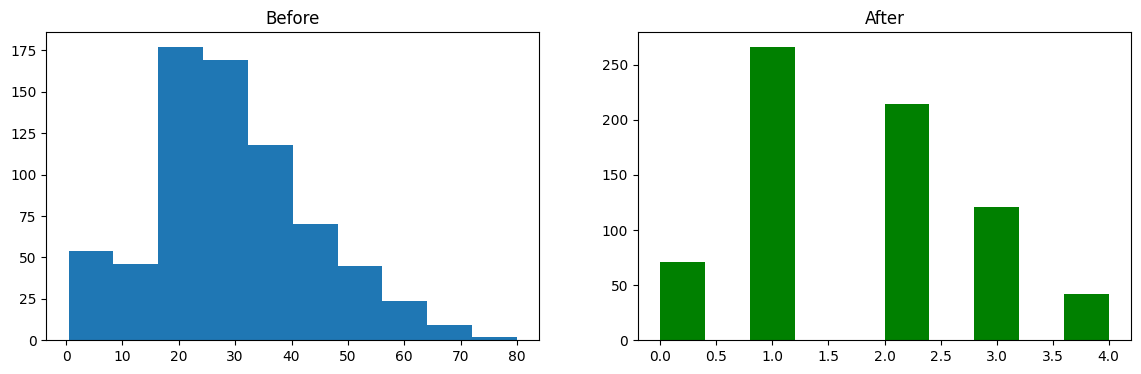

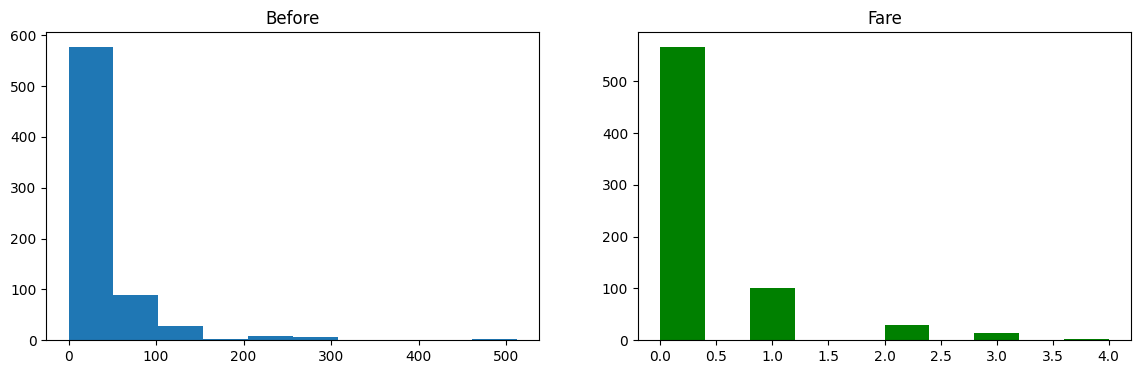

In [22]:
binning(15,'uniform')

# Binarization

In [23]:
df_2 = pd.read_csv("DATASET/titanic.csv",usecols=['Age','Fare','SibSp','Parch','Survived'])
df_2.head(2)

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833


In [24]:
df_2.isnull().sum()

Survived      0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

In [25]:
df_2.dropna(inplace=True)

In [27]:
df_2.head(4)

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000


In [28]:
df_2['family']=df_2['SibSp']+df_2['Parch']

In [29]:
df_2['family']

0      1
1      1
2      0
3      1
4      0
      ..
885    5
886    0
887    0
889    0
890    0
Name: family, Length: 714, dtype: int64

In [30]:
df_2.drop(columns =['SibSp','Parch'],inplace=True)

In [32]:
df_2.head(4)

,Survived,Age,Fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1


In [33]:
# independent and dependent col
X = df_2.drop(columns=['Survived'])
y = df_2['Survived']

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


In [35]:
X_train.head(2)

,Age,Fare,family
812,35.0,10.5000,0
448,5.0,19.2583,3


In [38]:
# train model wothout binarization
model =DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
accuracy  = accuracy_score(y_test,y_pred)
print(accuracy)

cross = np.mean(cross_val_score(model,X_train,y_train,scoring='accuracy',cv =15))
print(cross)

0.6033519553072626
0.6446031746031746


In [42]:
# apply the binarization see the accuracy 
from sklearn.preprocessing import Binarizer
binarization = Binarizer(copy=False)
X_train_b =binarization.fit_transform(X_train[['family']])
X_test_b=binarization.transform(X_test[['family']])

In [46]:
# create a dataframe of transformed array 
X_train_b_df =pd.DataFrame(X_train_b,columns=['family_binarized'],index =X_train.index)
# combine it with existing column
X_train_combine =pd.concat(
    [X_train[['Age','Fare']],X_train_b_df],
    axis =1
)

# see the data
X_train_combine

,Age,Fare,family_binarized
812,35.0,10.5000,0
448,5.0,19.2583,1
657,32.0,15.5000,1
311,18.0,262.3750,1
430,28.0,26.5500,0
...,...,...,...
92,46.0,61.1750,1
134,25.0,13.0000,0
337,41.0,134.5000,0
548,33.0,20.5250,1


In [56]:
# alternate method is to use the column Transformer 
from sklearn.compose import ColumnTransformer
transform = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])
],remainder='passthrough')

# fit the data
X_train_trans_b = transform.fit_transform(X_train)
X_test_trans_b = transform.transform(X_test)

# create a dataframe of tranformed data
pd.DataFrame(X_train_trans_b,columns=['family','Age','Fare'])


# # now train your model 
model = DecisionTreeClassifier()
model.fit(X_train_trans_b,y_train)

y_pred = model.predict(X_test_trans_b)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

cross_val = np.mean(cross_val_score(model,X_train_trans_b,y_train,scoring='accuracy',cv =15))
print(cross_val)

0.5977653631284916
0.638994708994709
